<u>References:</u><br>
(1) https://medium.com/@piyushkashyap045/transfer-learning-in-pytorch-fine-tuning-pretrained-models-for-custom-datasets-6737b03d6fa2 <br>
(2) https://stackoverflow.com/questions/48630313/vgg16-trained-on-grayscale-imagenet/68393374#68393374 <br>
(3) https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8 <br>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay, precision_recall_curve, \
accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
import torchvision
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torchsummary import summary

In [3]:
input_fpath = '/content/drive/MyDrive/Google AI Studio/chest_xray_resized_new'
output_fpath = '/content/drive/MyDrive/Google AI Studio/model_output'

In [4]:
def target_transform(x):
    return x

def load_datasets(train_path, val_path, test_path):
    # Pre-trained models expect inputs normalized to a specific range. Matching the normalization ensures consistency and better transfer learning performance.
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    val_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])  # by default, transforms.ToTensor() will output 3 channels (make 3 identical copies of the original grayscale channel). VGG16 model which requires 3 channels
    train_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])
    train_dataset = datasets.ImageFolder(train_path, transform=train_img_transform, target_transform = target_transform)
    val_dataset = datasets.ImageFolder(val_path, transform=val_img_transform, target_transform = target_transform)
    test_dataset = datasets.ImageFolder(test_path, transform=val_img_transform, target_transform = target_transform)
    print(f"Train set size: {len(train_dataset)}, Validation set size: {len(val_dataset)}, Test set size: {len(test_dataset)}")
    return train_dataset, val_dataset, test_dataset

In [5]:
# load all datasets
train_set, val_set, test_set = load_datasets(input_fpath + "/train", input_fpath + "/val", input_fpath + "/test")

Train set size: 4184, Validation set size: 1048, Test set size: 624


In [6]:
# response variable class labels
print(train_set.class_to_idx)
print(val_set.class_to_idx)
print(test_set.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
def construct_dataloaders(train_set, val_set, test_set, batch_size, shuffle=True):
    # 增加了 num_workers=2 和 pin_memory=True 来加速数据从 CPU 到 GPU 的加载
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size, shuffle, num_workers=2, pin_memory=True)
    val_dataloader = torch.utils.data.DataLoader(val_set, batch_size, num_workers=2, pin_memory=True)
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size, num_workers=2, pin_memory=True)
    return train_dataloader, val_dataloader, test_dataloader

In [8]:
# specify data loaders for VGG16 workflow
batch_size = 60
train_dataloader, val_dataloader, test_dataloader = construct_dataloaders(train_set, val_set, test_set, batch_size, True)

In [9]:
# 强制安装互相匹配的 torch 和 torch_xla 版本（例如 2.9.0）
!pip install torch==2.9.0 torchvision torch_xla==2.9.0



In [10]:
import torch
# device for running VGG16 model (GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [11]:
# Load the pre-trained VGG16 model
model = models.vgg16(weights='DEFAULT')

# Replace the output layer of the classifier part of the VGG16 model (the original model has 1000 out_features)
model.classifier[-1] = nn.Linear(in_features=model.classifier[-1].in_features, out_features=2) # for binary classification, out_features = 2

# Print summary while model is still on CPU
summary(model, input_size=(3, 224, 224), device="cpu")

# Move the model to the GPU device
model = model.to(device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [12]:
# Freeze the weights in all layers except for those in the classifier layers
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

In [13]:
# Verify trainable vs. frozen parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({trainable_params/total_params*100:.2f}%)")
print(f"Frozen parameters:    {frozen_params:,}  ({frozen_params/total_params*100:.2f}%)")

Total parameters:     134,268,738
Trainable parameters: 119,554,050  (89.04%)
Frozen parameters:    14,714,688  (10.96%)


In [14]:
# Define the loss function
criterion = nn.CrossEntropyLoss() # suitable for classification tasks

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.00005) # a smaller learning rate is recommended for transfer learning (when fine-tuning lots of layers/weights in a pre-trained model)

In [15]:
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, path=output_fpath + '/checkpoint_vgg16_balanced.pt', verbose=True):
        '''
        An early stopping mechanism prevents CNN from overfitting the training data by monitering the change of the loss function on the validation set
        after each training epoch.
        '''
        self.patience = patience # how long to wait after the last best improvement before stopping
        self.delta = delta # the minimum change in validation loss that we care about
        self.path = path
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Save checkpoint if improvement observed
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Model improved; checkpoint saved at loss {val_loss:.4f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                print("Early stopping triggered.")
                return True  # Signal to stop training
        return False

In [16]:
# Instantiate an early stopping controller
early_stopping = EarlyStopping(patience=5, delta=0.01)

In [17]:
# Training loop with early stopping and checkpointing
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # training within each epoch
    model.train() # Set model to training mode
    train_loss = 0.0
    print("Epoch {} Training...".format(epoch))
    for batch_idx, (data, target) in enumerate(train_dataloader):
        # print("Batch", batch_idx)
        data, target = data.to(device), target.to(device) # Move data to device (GPU/CPU)
        optimizer.zero_grad() # Reset parameter gradients to zero
        output = model(data) # Forward pass
        loss = criterion(output, target) # Compute the loss function for the batch
        loss.backward() # Back propogation
        optimizer.step() # Update weights (Standard PyTorch step for GPU)
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_dataloader)) # Loss function averaged over all batches

    # using validation set to monitor the model performance after each training epoch
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    print("Epoch {} Evaluation...".format(epoch))
    with torch.no_grad(): # This method disables the gradient calculation which reduces the memory consumption for computations
        for data, target in val_dataloader:
            data, target = data.to(device), target.to(device) # Move data to device
            output = model(data) # Forward pass
            loss = criterion(output, target) # Compute the loss function for the batch
            val_loss += loss.item()
    val_loss /= len(val_dataloader)
    val_losses.append(val_loss) # Loss function averaged over all batches

    # Early stopping check
    if early_stopping.check_early_stop(val_loss):
        print(f"Stopping training at epoch {epoch+1}")
        break

Epoch 0 Training...
Epoch 0 Evaluation...
Model improved; checkpoint saved at loss 0.0659
Epoch 1 Training...
Epoch 1 Evaluation...
Model improved; checkpoint saved at loss 0.0515
Epoch 2 Training...
Epoch 2 Evaluation...
Epoch 3 Training...
Epoch 3 Evaluation...
Epoch 4 Training...
Epoch 4 Evaluation...
Epoch 5 Training...
Epoch 5 Evaluation...
Epoch 6 Training...
Epoch 6 Evaluation...
Early stopping triggered.
Stopping training at epoch 7


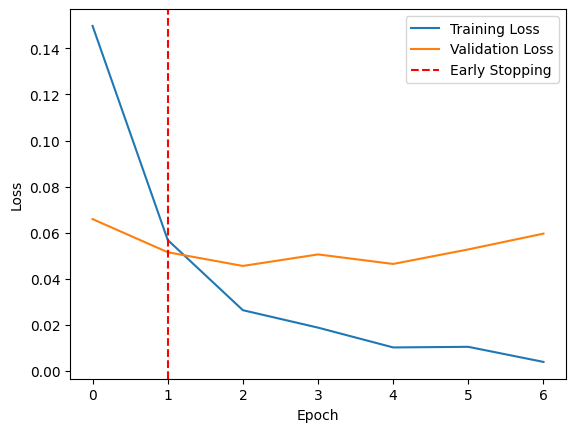

In [18]:
# Load best model checkpoint after early stopping
model.load_state_dict(torch.load(early_stopping.path))

# Final loss vs. epoch plot for both training and validation sets
epoch_list = np.arange(0, len(val_losses))
plt.plot(epoch_list, train_losses, label="Training Loss")
plt.plot(epoch_list, val_losses, label="Validation Loss")
plt.axvline(x=len(val_losses)-early_stopping.no_improvement_count-1, color='r', linestyle='--', label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
# Iterate over the test set batches to generate predicted probabilities for PNEUMONIA
model.eval() # Set model to evaluation mode
preds_list = []
y_list = []
with torch.no_grad(): # disabling the gradient calculation when evaluating model performance on test set
   for images, labels in test_dataloader:
       # Move data to the same device as the model (GPU)
       images, labels = images.to(device), labels.to(device)

       # Get predicted probabilities for test data batch
       outputs = model(images)
       # Convert the raw values in the output neurons to predicted probabilities:
       # dim is the dimension along which softmax will be computed. In this case, dim = 0 corresponds to indices for observations in the batch, dim = 1 corresponds to the raw output values of each observation
       preds = F.softmax(outputs, dim=1)

       # Move predictions and labels back to CPU for numpy conversion later
       preds_list.append(preds.cpu())
       y_list.append(labels.cpu())
pred_probabilities = torch.cat(preds_list, dim = 0).numpy()[:,1]
actual_y = torch.cat(y_list, dim = 0).numpy()

AUC = 0.9908


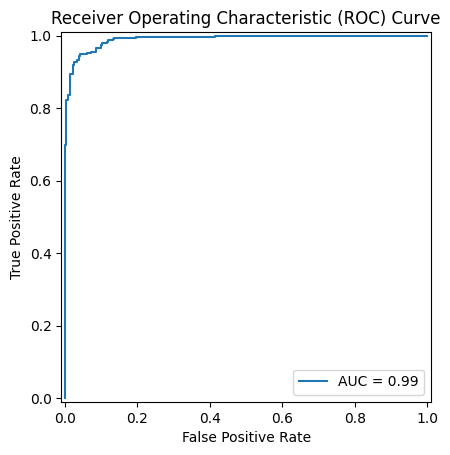

In [20]:
# ROC-AUC on test set
print("AUC =", round(roc_auc_score(actual_y, pred_probabilities), 4))
fpr, tpr, thresholds = roc_curve(actual_y, pred_probabilities)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(tpr = tpr, fpr = fpr, roc_auc = roc_auc)
display.plot()
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.show()

In [21]:
# Tune the threshold via optimizing the F1 score of the minority class (using the validation set: balancing the tradeoff between precision and recall for the NORMAL class)
## Generate predicted probabilities for PNEUMONIA
model.eval() # Set model to evaluation mode
preds_list = []
y_list = []
with torch.no_grad():
   for images, labels in val_dataloader:
       # Move data to the same device as the model (GPU)
       images, labels = images.to(device), labels.to(device)

       # Get predicted probabilities for test data batch
       outputs = model(images)
       preds = F.softmax(outputs, dim=1)

       # Move predictions and labels back to CPU for numpy conversion later
       preds_list.append(preds.cpu())
       y_list.append(labels.cpu())
pred_probabilities_val = torch.cat(preds_list, dim = 0).numpy()[:,1]
actual_y_val = torch.cat(y_list, dim = 0).numpy()
## Get precision/recall/threshold values
precision, recall, thresholds = precision_recall_curve(1 - actual_y_val, 1 - pred_probabilities_val)
## Calculate F1 scores
f1_scores = 2 * recall * precision / (recall + precision)
## Find the threshold for the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = 1 - thresholds[best_idx]
print("Best threshold =", best_threshold)

Best threshold = 0.7319206


Accuracy = 0.9167
Balanced accuracy = 0.8897
F1 score = 0.9373
True positive rate (sensitivity, recall) = 0.9974
True negative rate (specificity) = 0.7821
Positive predictive value (precision) = 0.8841
Negative predictive value = 0.9946
Confusion matrix:


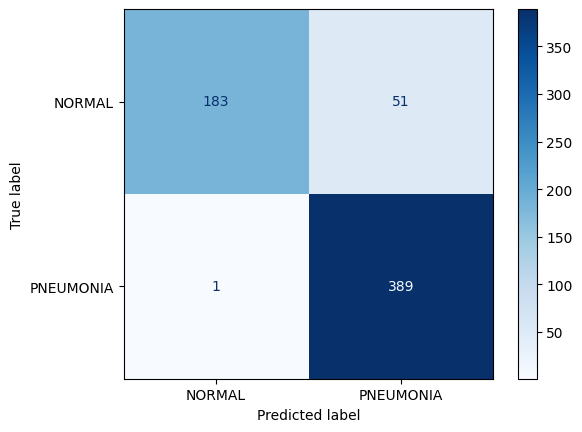

In [22]:
# Other evaluation metrics that depend on threshold:
pred_y = (pred_probabilities > best_threshold).astype(int)
print("Accuracy =", round(accuracy_score(actual_y, pred_y),4))
print("Balanced accuracy =", round(balanced_accuracy_score(actual_y, pred_y),4))
print("F1 score =", round(f1_score(actual_y, pred_y),4))
print("True positive rate (sensitivity, recall) =", round(recall_score(actual_y, pred_y),4))
print("True negative rate (specificity) =", round(recall_score(actual_y, pred_y, pos_label=0),4))
print("Positive predictive value (precision) =", round(precision_score(actual_y, pred_y),4))
print("Negative predictive value =", round(precision_score(actual_y, pred_y, pos_label=0),4))
print("Confusion matrix:")
cm = confusion_matrix(actual_y, pred_y, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL','PNEUMONIA'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [23]:
# class MyDataset(Dataset):
#     def __getitem__(self, index):
#         data, target = self.data[index], self.targets[index]
#         # Explicitly return the index along with data
#         return data, target, index

# # Usage in training loop
# for batch_idx, (data, target, sample_indices) in enumerate(dataloader):
#     print(f"Indices in this batch: {sample_indices}")

In [53]:
import os
import sys
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import cv2
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"
    ])
    import cv2


# ============================================================
# 0. Check required existing variables
# ============================================================

required_vars_grad_cam = [
    "model",
    "device",
    "test_set",
    "test_dataloader",
    "best_threshold",
    "output_fpath",
]

missing_vars_grad_cam = [
    var_name for var_name in required_vars_grad_cam
    if var_name not in globals()
]

if missing_vars_grad_cam:
    raise RuntimeError(
        "Missing required variables from the original VGG16 notebook: "
        + ", ".join(missing_vars_grad_cam)
        + ". Run the original training/evaluation cells before this Grad-CAM section."
    )

model.eval()

for parameter_grad_cam in model.parameters():
    parameter_grad_cam.requires_grad_(True)

grad_cam_fpath = os.path.join(output_fpath, "gradcam_vgg16_precise_continuation")
grad_cam_review_fpath = os.path.join(grad_cam_fpath, "review_cases")
grad_cam_final_fpath = os.path.join(grad_cam_fpath, "final_report_cases")

os.makedirs(grad_cam_fpath, exist_ok=True)
os.makedirs(grad_cam_review_fpath, exist_ok=True)
os.makedirs(grad_cam_final_fpath, exist_ok=True)

print("Grad-CAM output folder:", grad_cam_fpath)
print("Review folder:", grad_cam_review_fpath)
print("Final report folder:", grad_cam_final_fpath)


Grad-CAM output folder: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation
Review folder: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/review_cases
Final report folder: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/final_report_cases


In [73]:
# ============================================================
# 1. Class mapping
# ============================================================

class_names_grad_cam = list(test_set.classes)
class_to_idx_grad_cam = dict(test_set.class_to_idx)

print("Class order from existing test_set:", class_to_idx_grad_cam)

if "NORMAL" not in class_to_idx_grad_cam or "PNEUMONIA" not in class_to_idx_grad_cam:
    raise ValueError(
        "Expected classes to include NORMAL and PNEUMONIA. "
        f"Found classes: {class_names_grad_cam}"
    )

normal_idx_grad_cam = int(class_to_idx_grad_cam["NORMAL"])
pneumonia_idx_grad_cam = int(class_to_idx_grad_cam["PNEUMONIA"])

if len(class_names_grad_cam) != 2:
    raise ValueError(
        "This code assumes binary classification. "
        f"Found classes: {class_names_grad_cam}"
    )

print("normal_idx_grad_cam:", normal_idx_grad_cam)
print("pneumonia_idx_grad_cam:", pneumonia_idx_grad_cam)
print("Using existing best_threshold for P(PNEUMONIA):", float(best_threshold))

Class order from existing test_set: {'NORMAL': 0, 'PNEUMONIA': 1}
normal_idx_grad_cam: 0
pneumonia_idx_grad_cam: 1
Using existing best_threshold for P(PNEUMONIA): 0.7345407605171204


In [74]:


# ============================================================
# 2. Collect or reuse test predictions
# ============================================================

def collect_test_probabilities_grad_cam(model_instance_grad_cam, dataloader_grad_cam, device_grad_cam):
    """
    Collect probabilities from the existing trained model and existing test_dataloader.

    Returns
    -------
    probabilities_grad_cam : np.ndarray, shape [N, 2]
    labels_grad_cam : np.ndarray, shape [N]
    """

    model_instance_grad_cam.eval()

    probabilities_list_grad_cam = []
    labels_list_grad_cam = []

    with torch.no_grad():
        for images_grad_cam, labels_grad_cam in dataloader_grad_cam:
            images_grad_cam = images_grad_cam.to(device_grad_cam)
            labels_grad_cam = labels_grad_cam.to(device_grad_cam)

            logits_grad_cam = model_instance_grad_cam(images_grad_cam)
            probabilities_batch_grad_cam = F.softmax(logits_grad_cam, dim=1)

            probabilities_list_grad_cam.append(probabilities_batch_grad_cam.detach().cpu())
            labels_list_grad_cam.append(labels_grad_cam.detach().cpu())

    probabilities_grad_cam = torch.cat(probabilities_list_grad_cam, dim=0).numpy()
    labels_grad_cam = torch.cat(labels_list_grad_cam, dim=0).numpy()

    return probabilities_grad_cam, labels_grad_cam


can_reuse_original_test_predictions_grad_cam = (
    "pred_probabilities" in globals()
    and "actual_y" in globals()
    and len(pred_probabilities) == len(test_set)
    and len(actual_y) == len(test_set)
)

if can_reuse_original_test_predictions_grad_cam:
    print("Reusing pred_probabilities and actual_y from the original VGG16 notebook.")
    actual_y_grad_cam = np.asarray(actual_y).astype(int)
    p_pneumonia_grad_cam = np.asarray(pred_probabilities).astype(float)

    p_normal_grad_cam = 1.0 - p_pneumonia_grad_cam

    test_probs_grad_cam = np.zeros((len(test_set), 2), dtype=float)
    test_probs_grad_cam[:, normal_idx_grad_cam] = p_normal_grad_cam
    test_probs_grad_cam[:, pneumonia_idx_grad_cam] = p_pneumonia_grad_cam
else:
    print("Original prediction arrays were not found or mismatched. Recomputing predictions from test_dataloader.")
    test_probs_grad_cam, actual_y_grad_cam = collect_test_probabilities_grad_cam(
        model_instance_grad_cam=model,
        dataloader_grad_cam=test_dataloader,
        device_grad_cam=device,
    )

    p_normal_grad_cam = test_probs_grad_cam[:, normal_idx_grad_cam]
    p_pneumonia_grad_cam = test_probs_grad_cam[:, pneumonia_idx_grad_cam]


pred_y_grad_cam = np.where(
    p_pneumonia_grad_cam > float(best_threshold),
    pneumonia_idx_grad_cam,
    normal_idx_grad_cam,
)

pred_class_probability_grad_cam = np.where(
    pred_y_grad_cam == pneumonia_idx_grad_cam,
    p_pneumonia_grad_cam,
    p_normal_grad_cam,
)

decision_margin_grad_cam = np.abs(p_pneumonia_grad_cam - float(best_threshold))

image_paths_grad_cam = [sample_grad_cam[0] for sample_grad_cam in test_set.samples]
image_labels_from_paths_grad_cam = np.array(
    [sample_grad_cam[1] for sample_grad_cam in test_set.samples],
    dtype=int,
)

if not np.array_equal(image_labels_from_paths_grad_cam, actual_y_grad_cam):
    warnings.warn(
        "test_dataloader labels do not match test_set.samples. "
        "This usually means test_dataloader was created with shuffle=True. "
        "Grad-CAM image paths may not align with predictions. "
        "Recreate test_dataloader with shuffle=False if this warning appears."
    )


def assign_case_type_grad_cam(true_label_grad_cam, pred_label_grad_cam):
    if true_label_grad_cam == pneumonia_idx_grad_cam and pred_label_grad_cam == pneumonia_idx_grad_cam:
        return "TP"
    if true_label_grad_cam == normal_idx_grad_cam and pred_label_grad_cam == normal_idx_grad_cam:
        return "TN"
    if true_label_grad_cam == normal_idx_grad_cam and pred_label_grad_cam == pneumonia_idx_grad_cam:
        return "FP"
    if true_label_grad_cam == pneumonia_idx_grad_cam and pred_label_grad_cam == normal_idx_grad_cam:
        return "FN"
    return "OTHER"


pred_df_grad_cam = pd.DataFrame({
    "image_path": image_paths_grad_cam,
    "true_label": actual_y_grad_cam.astype(int),
    "pred_label": pred_y_grad_cam.astype(int),
    "true_class": [class_names_grad_cam[int(label_grad_cam)] for label_grad_cam in actual_y_grad_cam],
    "pred_class": [class_names_grad_cam[int(label_grad_cam)] for label_grad_cam in pred_y_grad_cam],
    "p_normal": p_normal_grad_cam,
    "p_pneumonia": p_pneumonia_grad_cam,
    "pred_class_probability": pred_class_probability_grad_cam,
    "decision_margin": decision_margin_grad_cam,
})

pred_df_grad_cam["correct"] = pred_df_grad_cam["true_label"] == pred_df_grad_cam["pred_label"]

pred_df_grad_cam["case_type"] = [
    assign_case_type_grad_cam(true_label_grad_cam, pred_label_grad_cam)
    for true_label_grad_cam, pred_label_grad_cam
    in zip(pred_df_grad_cam["true_label"], pred_df_grad_cam["pred_label"])
]

pred_table_path_grad_cam = os.path.join(
    grad_cam_fpath,
    "vgg16_test_predictions_for_precise_gradcam.csv",
)
pred_df_grad_cam.to_csv(pred_table_path_grad_cam, index=False)

print("Saved prediction table:", pred_table_path_grad_cam)

display(
    pd.crosstab(
        pred_df_grad_cam["true_class"],
        pred_df_grad_cam["pred_class"],
        rownames=["True"],
        colnames=["Predicted"],
    )
)

display(
    pred_df_grad_cam["case_type"]
    .value_counts()
    .rename_axis("case_type")
    .reset_index(name="count")
)






Reusing pred_probabilities and actual_y from the original VGG16 notebook.
Saved prediction table: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/vgg16_test_predictions_for_precise_gradcam.csv


Predicted,NORMAL,PNEUMONIA
True,,
NORMAL,183,51
PNEUMONIA,1,389


,case_type,count
0,TP,389
1,TN,183
2,FP,51
3,FN,1


In [75]:
# ============================================================
# 3. Fix VGG16 inplace ReLU before Grad-CAM hooks
# ============================================================

def disable_inplace_relu_grad_cam(model_instance_grad_cam):
    """
    VGG16 uses nn.ReLU(inplace=True) by default.
    Inplace ReLU can overwrite hooked convolution outputs and break Grad-CAM gradients.
    This function changes all ReLU modules to inplace=False.
    """

    changed_layers_grad_cam = []

    for module_name_grad_cam, module_instance_grad_cam in model_instance_grad_cam.named_modules():
        if isinstance(module_instance_grad_cam, nn.ReLU) and module_instance_grad_cam.inplace:
            module_instance_grad_cam.inplace = False
            changed_layers_grad_cam.append(module_name_grad_cam)

    return model_instance_grad_cam, changed_layers_grad_cam


model, changed_relu_layers_grad_cam = disable_inplace_relu_grad_cam(model)
model.eval()

for parameter_grad_cam in model.parameters():
    parameter_grad_cam.requires_grad_(True)

print("ReLU layers changed to inplace=False:", changed_relu_layers_grad_cam)



ReLU layers changed to inplace=False: []


In [76]:
# ============================================================
# 4. Target convolutional layer
# ============================================================

def get_last_conv_layer_name_grad_cam(model_instance_grad_cam):
    """
    Find the last Conv2d layer in the existing VGG16 model.
    For standard VGG16, this is usually features.28.
    """

    last_conv_name_grad_cam = None

    for module_name_grad_cam, module_instance_grad_cam in model_instance_grad_cam.named_modules():
        if isinstance(module_instance_grad_cam, nn.Conv2d):
            last_conv_name_grad_cam = module_name_grad_cam

    if last_conv_name_grad_cam is None:
        raise RuntimeError("No nn.Conv2d layer was found in the existing model.")

    return last_conv_name_grad_cam


target_layer_name_grad_cam = get_last_conv_layer_name_grad_cam(model)

print("Target convolutional layer for Grad-CAM:", target_layer_name_grad_cam)



Target convolutional layer for Grad-CAM: features.28


In [77]:
# ============================================================
# 5. Precise Grad-CAM class
# ============================================================

class PreciseGradCAM:
    """
    Custom Grad-CAM using:
        forward hook on the target convolutional layer
        tensor-level gradient hook on the target layer output

    This avoids the old register_backward_hook API and is more stable.

    CAM formula:
        alpha_k = mean_{i,j}(d score / d A_k(i,j))
        CAM = ReLU(sum_k alpha_k A_k)

    For this binary model, target_score_mode='margin' uses:
        logit(target_class) - logit(opposite_class)
    """

    def __init__(self, model_instance_grad_cam, target_layer_name_grad_cam):
        self.model_instance_grad_cam = model_instance_grad_cam
        self.target_layer_name_grad_cam = target_layer_name_grad_cam

        self.features_grad_cam = None
        self.gradients_grad_cam = None
        self.forward_handle_grad_cam = None

        self.model_instance_grad_cam.eval()
        self._register_forward_hook_grad_cam()

    def _save_gradient_grad_cam(self, gradient_grad_cam):
        self.gradients_grad_cam = gradient_grad_cam

    def _register_forward_hook_grad_cam(self):
        target_layer_found_grad_cam = False

        def forward_hook_grad_cam(module_grad_cam, input_grad_cam, output_grad_cam):
            self.features_grad_cam = output_grad_cam

            if output_grad_cam.requires_grad:
                output_grad_cam.register_hook(self._save_gradient_grad_cam)

        for module_name_grad_cam, module_instance_grad_cam in self.model_instance_grad_cam.named_modules():
            if module_name_grad_cam == self.target_layer_name_grad_cam:
                self.forward_handle_grad_cam = module_instance_grad_cam.register_forward_hook(
                    forward_hook_grad_cam
                )
                target_layer_found_grad_cam = True
                break

        if not target_layer_found_grad_cam:
            raise ValueError(
                f"Target layer '{self.target_layer_name_grad_cam}' was not found."
            )

    def remove_hooks_grad_cam(self):
        if self.forward_handle_grad_cam is not None:
            self.forward_handle_grad_cam.remove()
            self.forward_handle_grad_cam = None

    def _get_opposite_class_grad_cam(self, target_class_grad_cam):
        if int(target_class_grad_cam) == normal_idx_grad_cam:
            return pneumonia_idx_grad_cam
        if int(target_class_grad_cam) == pneumonia_idx_grad_cam:
            return normal_idx_grad_cam
        raise ValueError(f"Unexpected target_class_grad_cam: {target_class_grad_cam}")

    def _get_target_score_grad_cam(
        self,
        output_logits_grad_cam,
        target_class_grad_cam,
        target_score_mode_grad_cam="margin",
    ):
        target_class_grad_cam = int(target_class_grad_cam)

        if target_score_mode_grad_cam == "logit":
            return output_logits_grad_cam[0, target_class_grad_cam]

        if target_score_mode_grad_cam == "margin":
            opposite_class_grad_cam = self._get_opposite_class_grad_cam(target_class_grad_cam)
            return (
                output_logits_grad_cam[0, target_class_grad_cam]
                - output_logits_grad_cam[0, opposite_class_grad_cam]
            )

        raise ValueError("target_score_mode_grad_cam must be 'margin' or 'logit'.")

    def generate_heatmap_grad_cam(
        self,
        input_tensor_grad_cam,
        target_class_grad_cam=None,
        target_score_mode_grad_cam="margin",
    ):
        """
        Generate normalized Grad-CAM heatmap for one image tensor.

        input_tensor_grad_cam must have shape [1, 3, H, W].
        """

        self.model_instance_grad_cam.eval()
        self.features_grad_cam = None
        self.gradients_grad_cam = None

        self.model_instance_grad_cam.zero_grad(set_to_none=True)

        output_logits_grad_cam = self.model_instance_grad_cam(input_tensor_grad_cam)

        if target_class_grad_cam is None:
            target_class_grad_cam = int(torch.argmax(output_logits_grad_cam, dim=1).item())
        else:
            target_class_grad_cam = int(target_class_grad_cam)

        target_score_grad_cam = self._get_target_score_grad_cam(
            output_logits_grad_cam=output_logits_grad_cam,
            target_class_grad_cam=target_class_grad_cam,
            target_score_mode_grad_cam=target_score_mode_grad_cam,
        )

        target_score_grad_cam.backward(retain_graph=False)

        if self.features_grad_cam is None:
            raise RuntimeError("Target layer feature maps were not captured.")

        if self.gradients_grad_cam is None:
            raise RuntimeError(
                "Target layer gradients were not captured. "
                "Check that model parameters require gradients and that inplace ReLU is disabled."
            )

        features_grad_cam = self.features_grad_cam.detach()
        gradients_grad_cam = self.gradients_grad_cam.detach()

        if features_grad_cam.ndim != 4 or gradients_grad_cam.ndim != 4:
            raise RuntimeError(
                "Expected feature maps and gradients to have shape [1, C, H, W]. "
                f"Got features={tuple(features_grad_cam.shape)}, "
                f"gradients={tuple(gradients_grad_cam.shape)}."
            )

        weights_grad_cam = torch.mean(
            gradients_grad_cam,
            dim=(2, 3),
            keepdim=True,
        )

        weighted_features_grad_cam = weights_grad_cam * features_grad_cam

        heatmap_tensor_grad_cam = torch.sum(
            weighted_features_grad_cam,
            dim=1,
        ).squeeze(0)

        heatmap_tensor_grad_cam = F.relu(heatmap_tensor_grad_cam)

        heatmap_min_grad_cam = torch.min(heatmap_tensor_grad_cam)
        heatmap_max_grad_cam = torch.max(heatmap_tensor_grad_cam)
        heatmap_range_grad_cam = heatmap_max_grad_cam - heatmap_min_grad_cam

        if float(heatmap_range_grad_cam.detach().cpu()) < 1e-8:
            heatmap_tensor_grad_cam = torch.zeros_like(heatmap_tensor_grad_cam)
            cam_valid_grad_cam = False
        else:
            heatmap_tensor_grad_cam = (
                heatmap_tensor_grad_cam - heatmap_min_grad_cam
            ) / (heatmap_range_grad_cam + 1e-8)
            cam_valid_grad_cam = True

        heatmap_grad_cam = heatmap_tensor_grad_cam.detach().cpu().numpy()

        probabilities_grad_cam = F.softmax(output_logits_grad_cam, dim=1)[0].detach().cpu().numpy()

        diagnostics_grad_cam = {
            "target_class": int(target_class_grad_cam),
            "target_class_name": class_names_grad_cam[int(target_class_grad_cam)],
            "target_score_mode": target_score_mode_grad_cam,
            "target_score": float(target_score_grad_cam.detach().cpu()),
            "p_normal_from_forward": float(probabilities_grad_cam[normal_idx_grad_cam]),
            "p_pneumonia_from_forward": float(probabilities_grad_cam[pneumonia_idx_grad_cam]),
            "feature_shape": tuple(features_grad_cam.shape),
            "gradient_shape": tuple(gradients_grad_cam.shape),
            "cam_min": float(np.min(heatmap_grad_cam)),
            "cam_max": float(np.max(heatmap_grad_cam)),
            "cam_mean": float(np.mean(heatmap_grad_cam)),
            "cam_valid": bool(cam_valid_grad_cam),
        }

        return heatmap_grad_cam, int(target_class_grad_cam), diagnostics_grad_cam


if "grad_cam_generator_grad_cam" in globals():
    try:
        grad_cam_generator_grad_cam.remove_hooks_grad_cam()
        print("Old Grad-CAM forward hook removed.")
    except Exception as error_grad_cam:
        print("No old Grad-CAM hook removed:", error_grad_cam)

grad_cam_generator_grad_cam = PreciseGradCAM(
    model_instance_grad_cam=model,
    target_layer_name_grad_cam=target_layer_name_grad_cam,
)

print("PreciseGradCAM initialized successfully.")



Old Grad-CAM forward hook removed.
PreciseGradCAM initialized successfully.


In [78]:
# ============================================================
# 6. Image utilities
# ============================================================

def load_original_image_grad_cam(image_path_grad_cam):
    image_pil_grad_cam = Image.open(image_path_grad_cam).convert("RGB")
    image_rgb_grad_cam = np.array(image_pil_grad_cam).astype(np.float32) / 255.0
    return image_pil_grad_cam, image_rgb_grad_cam


def make_input_tensor_grad_cam(image_pil_grad_cam):
    """
    Use the existing test_set.transform from the original notebook.
    This keeps Grad-CAM preprocessing consistent with the trained VGG16 model.
    """

    if test_set.transform is None:
        raise ValueError("test_set.transform is None. Grad-CAM needs the same preprocessing as model evaluation.")

    input_tensor_grad_cam = test_set.transform(image_pil_grad_cam)
    input_tensor_grad_cam = input_tensor_grad_cam.unsqueeze(0).to(device)
    return input_tensor_grad_cam


def resize_heatmap_to_image_grad_cam(heatmap_grad_cam, image_rgb_grad_cam):
    resized_heatmap_grad_cam = cv2.resize(
        heatmap_grad_cam.astype(np.float32),
        (image_rgb_grad_cam.shape[1], image_rgb_grad_cam.shape[0]),
        interpolation=cv2.INTER_LINEAR,
    )

    resized_heatmap_grad_cam = np.nan_to_num(resized_heatmap_grad_cam)

    heatmap_range_grad_cam = resized_heatmap_grad_cam.max() - resized_heatmap_grad_cam.min()

    if heatmap_range_grad_cam > 1e-8:
        resized_heatmap_grad_cam = (
            resized_heatmap_grad_cam - resized_heatmap_grad_cam.min()
        ) / (heatmap_range_grad_cam + 1e-8)

    return resized_heatmap_grad_cam


def overlay_heatmap_on_image_grad_cam(image_rgb_grad_cam, heatmap_grad_cam, alpha_grad_cam=0.45):
    heatmap_uint8_grad_cam = np.uint8(255 * np.clip(heatmap_grad_cam, 0, 1))

    heatmap_color_bgr_grad_cam = cv2.applyColorMap(
        heatmap_uint8_grad_cam,
        cv2.COLORMAP_JET,
    )

    heatmap_color_rgb_grad_cam = cv2.cvtColor(
        heatmap_color_bgr_grad_cam,
        cv2.COLOR_BGR2RGB,
    ).astype(np.float32) / 255.0

    overlay_rgb_grad_cam = (
        (1.0 - alpha_grad_cam) * image_rgb_grad_cam
        + alpha_grad_cam * heatmap_color_rgb_grad_cam
    )

    return np.clip(overlay_rgb_grad_cam, 0, 1)


def choose_target_class_grad_cam(row_grad_cam, target_mode_grad_cam="pred"):
    if target_mode_grad_cam == "pred":
        return int(row_grad_cam["pred_label"])

    if target_mode_grad_cam == "true":
        return int(row_grad_cam["true_label"])

    if isinstance(target_mode_grad_cam, int):
        return int(target_mode_grad_cam)

    raise ValueError("target_mode_grad_cam must be 'pred', 'true', or an integer class index.")


def generate_case_grad_cam(
    row_grad_cam,
    target_mode_grad_cam="pred",
    target_score_mode_grad_cam="margin",
):
    image_pil_grad_cam, image_rgb_grad_cam = load_original_image_grad_cam(
        row_grad_cam["image_path"]
    )

    input_tensor_grad_cam = make_input_tensor_grad_cam(image_pil_grad_cam)

    target_class_grad_cam = choose_target_class_grad_cam(
        row_grad_cam=row_grad_cam,
        target_mode_grad_cam=target_mode_grad_cam,
    )

    heatmap_small_grad_cam, target_class_grad_cam, diagnostics_grad_cam = (
        grad_cam_generator_grad_cam.generate_heatmap_grad_cam(
            input_tensor_grad_cam=input_tensor_grad_cam,
            target_class_grad_cam=target_class_grad_cam,
            target_score_mode_grad_cam=target_score_mode_grad_cam,
        )
    )

    heatmap_resized_grad_cam = resize_heatmap_to_image_grad_cam(
        heatmap_grad_cam=heatmap_small_grad_cam,
        image_rgb_grad_cam=image_rgb_grad_cam,
    )

    overlay_rgb_grad_cam = overlay_heatmap_on_image_grad_cam(
        image_rgb_grad_cam=image_rgb_grad_cam,
        heatmap_grad_cam=heatmap_resized_grad_cam,
        alpha_grad_cam=0.45,
    )

    return {
        "image_rgb": image_rgb_grad_cam,
        "heatmap": heatmap_resized_grad_cam,
        "overlay_rgb": overlay_rgb_grad_cam,
        "target_class": target_class_grad_cam,
        "diagnostics": diagnostics_grad_cam,
    }


def case_title_grad_cam(row_grad_cam, target_class_grad_cam, diagnostics_grad_cam):
    return (
        f"{row_grad_cam['case_type']} | "
        f"True: {row_grad_cam['true_class']} | "
        f"Pred: {row_grad_cam['pred_class']} | "
        f"CAM target: {class_names_grad_cam[int(target_class_grad_cam)]}\n"
        f"P(NORMAL)={row_grad_cam['p_normal']:.3f}, "
        f"P(PNEUMONIA)={row_grad_cam['p_pneumonia']:.3f}, "
        f"pred_prob={row_grad_cam['pred_class_probability']:.3f}, "
        f"margin={row_grad_cam['decision_margin']:.3f}, "
        f"cam_mean={diagnostics_grad_cam['cam_mean']:.4f}, "
        f"valid={diagnostics_grad_cam['cam_valid']}"
    )



In [79]:
# ============================================================
# 7. Rough lung-region screening
# ============================================================

def make_rough_lung_roi_mask_grad_cam(image_rgb_grad_cam):
    """
    Rough lung/chest ROI mask.
    This is not a medical lung segmentation mask.
    It is only used to screen whether Grad-CAM is roughly inside lung fields.
    """

    height_grad_cam, width_grad_cam = image_rgb_grad_cam.shape[:2]

    mask_grad_cam = np.zeros((height_grad_cam, width_grad_cam), dtype=np.uint8)

    y1_grad_cam = int(0.18 * height_grad_cam)
    y2_grad_cam = int(0.88 * height_grad_cam)
    x1_grad_cam = int(0.13 * width_grad_cam)
    x2_grad_cam = int(0.87 * width_grad_cam)

    mask_grad_cam[y1_grad_cam:y2_grad_cam, x1_grad_cam:x2_grad_cam] = 1

    center_x1_grad_cam = int(0.45 * width_grad_cam)
    center_x2_grad_cam = int(0.55 * width_grad_cam)
    mask_grad_cam[y1_grad_cam:y2_grad_cam, center_x1_grad_cam:center_x2_grad_cam] = 0

    kernel_grad_cam = np.ones((7, 7), np.uint8)
    mask_grad_cam = cv2.morphologyEx(mask_grad_cam, cv2.MORPH_CLOSE, kernel_grad_cam)

    return mask_grad_cam.astype(bool)


def compute_attention_ratios_grad_cam(image_rgb_grad_cam, heatmap_grad_cam):
    heatmap_grad_cam = np.nan_to_num(heatmap_grad_cam.astype(np.float32))
    total_attention_grad_cam = float(heatmap_grad_cam.sum()) + 1e-8

    height_grad_cam, width_grad_cam = heatmap_grad_cam.shape[:2]

    lung_mask_grad_cam = make_rough_lung_roi_mask_grad_cam(image_rgb_grad_cam)

    border_mask_grad_cam = np.zeros((height_grad_cam, width_grad_cam), dtype=bool)
    border_width_grad_cam = int(0.08 * min(height_grad_cam, width_grad_cam))

    border_mask_grad_cam[:border_width_grad_cam, :] = True
    border_mask_grad_cam[-border_width_grad_cam:, :] = True
    border_mask_grad_cam[:, :border_width_grad_cam] = True
    border_mask_grad_cam[:, -border_width_grad_cam:] = True

    upper_mask_grad_cam = np.zeros((height_grad_cam, width_grad_cam), dtype=bool)
    upper_mask_grad_cam[: int(0.18 * height_grad_cam), :] = True

    return {
        "rough_lung_attention_ratio": float(heatmap_grad_cam[lung_mask_grad_cam].sum() / total_attention_grad_cam),
        "border_attention_ratio": float(heatmap_grad_cam[border_mask_grad_cam].sum() / total_attention_grad_cam),
        "upper_attention_ratio": float(heatmap_grad_cam[upper_mask_grad_cam].sum() / total_attention_grad_cam),
    }


def auto_location_label_grad_cam(attention_ratios_grad_cam):
    lung_ratio_grad_cam = attention_ratios_grad_cam["rough_lung_attention_ratio"]
    border_ratio_grad_cam = attention_ratios_grad_cam["border_attention_ratio"]
    upper_ratio_grad_cam = attention_ratios_grad_cam["upper_attention_ratio"]

    if lung_ratio_grad_cam >= 0.55 and border_ratio_grad_cam < 0.25 and upper_ratio_grad_cam < 0.35:
        return "likely_lung_field"

    if border_ratio_grad_cam >= 0.30:
        return "likely_border_artifact"

    if upper_ratio_grad_cam >= 0.40:
        return "likely_upper_neck_or_marker"

    return "uncertain"

In [80]:
# ============================================================
# 8. Select review candidates
# ============================================================

def select_review_candidates_grad_cam(pred_df_input_grad_cam, n_per_case_grad_cam=6):
    selected_parts_grad_cam = []

    for case_type_grad_cam in ["TP", "TN", "FP", "FN"]:
        case_df_grad_cam = pred_df_input_grad_cam[
            pred_df_input_grad_cam["case_type"] == case_type_grad_cam
        ].copy()

        if len(case_df_grad_cam) == 0:
            continue

        if case_type_grad_cam in ["TP", "TN"]:
            candidate_df_grad_cam = case_df_grad_cam[
                (case_df_grad_cam["pred_class_probability"] >= 0.70)
                & (case_df_grad_cam["pred_class_probability"] <= 0.999)
            ]

            if len(candidate_df_grad_cam) == 0:
                candidate_df_grad_cam = case_df_grad_cam

            candidate_df_grad_cam = candidate_df_grad_cam.sort_values(
                ["pred_class_probability", "decision_margin"],
                ascending=[False, False],
            )
        else:
            candidate_df_grad_cam = case_df_grad_cam.sort_values(
                ["decision_margin", "pred_class_probability"],
                ascending=[False, False],
            )

        selected_parts_grad_cam.append(candidate_df_grad_cam.head(n_per_case_grad_cam))

    if len(selected_parts_grad_cam) == 0:
        return pd.DataFrame(columns=pred_df_input_grad_cam.columns)

    review_df_grad_cam = pd.concat(selected_parts_grad_cam, axis=0).reset_index(drop=True)
    review_df_grad_cam.insert(0, "review_id", np.arange(1, len(review_df_grad_cam) + 1))

    return review_df_grad_cam


review_df_grad_cam = select_review_candidates_grad_cam(
    pred_df_input_grad_cam=pred_df_grad_cam,
    n_per_case_grad_cam=6,
)

print("Number of Grad-CAM review candidates:", len(review_df_grad_cam))

display(
    review_df_grad_cam[
        [
            "review_id",
            "case_type",
            "true_class",
            "pred_class",
            "p_normal",
            "p_pneumonia",
            "pred_class_probability",
            "decision_margin",
            "image_path",
        ]
    ]
)


Number of Grad-CAM review candidates: 19


,review_id,case_type,true_class,pred_class,p_normal,p_pneumonia,pred_class_probability,decision_margin,image_path
0,1,TP,PNEUMONIA,PNEUMONIA,0.001009,0.998991,0.998991,0.264450,/content/drive/MyDrive/Google AI Studio/chest_...
1,2,TP,PNEUMONIA,PNEUMONIA,0.001078,0.998922,0.998922,0.264382,/content/drive/MyDrive/Google AI Studio/chest_...
2,3,TP,PNEUMONIA,PNEUMONIA,0.001083,0.998917,0.998917,0.264376,/content/drive/MyDrive/Google AI Studio/chest_...
3,4,TP,PNEUMONIA,PNEUMONIA,0.001269,0.998731,0.998731,0.264190,/content/drive/MyDrive/Google AI Studio/chest_...
4,5,TP,PNEUMONIA,PNEUMONIA,0.001487,0.998513,0.998513,0.263972,/content/drive/MyDrive/Google AI Studio/chest_...
5,6,TP,PNEUMONIA,PNEUMONIA,0.001497,0.998503,0.998503,0.263963,/content/drive/MyDrive/Google AI Studio/chest_...
6,7,TN,NORMAL,NORMAL,0.998940,0.001060,0.998940,0.733481,/content/drive/MyDrive/Google AI Studio/chest_...
7,8,TN,NORMAL,NORMAL,0.998871,0.001129,0.998871,0.733412,/content/drive/MyDrive/Google AI Studio/chest_...
8,9,TN,NORMAL,NORMAL,0.998696,0.001304,0.998696,0.733236,/content/drive/MyDrive/Google AI Studio/chest_...
9,10,TN,NORMAL,NORMAL,0.998473,0.001527,0.998473,0.733014,/content/drive/MyDrive/Google AI Studio/chest_...


In [81]:
# ============================================================
# 9. Generate review images and review table
# ============================================================

review_records_grad_cam = []

for _, row_grad_cam in review_df_grad_cam.iterrows():
    result_grad_cam = generate_case_grad_cam(
        row_grad_cam=row_grad_cam,
        target_mode_grad_cam="pred",
        target_score_mode_grad_cam="margin",
    )

    image_rgb_grad_cam = result_grad_cam["image_rgb"]
    heatmap_grad_cam = result_grad_cam["heatmap"]
    overlay_rgb_grad_cam = result_grad_cam["overlay_rgb"]
    target_class_grad_cam = result_grad_cam["target_class"]
    diagnostics_grad_cam = result_grad_cam["diagnostics"]

    attention_ratios_grad_cam = compute_attention_ratios_grad_cam(
        image_rgb_grad_cam=image_rgb_grad_cam,
        heatmap_grad_cam=heatmap_grad_cam,
    )

    auto_label_grad_cam = auto_location_label_grad_cam(attention_ratios_grad_cam)

    rough_lung_mask_grad_cam = make_rough_lung_roi_mask_grad_cam(image_rgb_grad_cam)

    fig_grad_cam, axes_grad_cam = plt.subplots(
        1,
        4,
        figsize=(16, 4),
        constrained_layout=True,
    )

    axes_grad_cam[0].imshow(image_rgb_grad_cam)
    axes_grad_cam[0].set_title("Original")
    axes_grad_cam[0].axis("off")

    axes_grad_cam[1].imshow(heatmap_grad_cam, cmap="jet", vmin=0, vmax=1)
    axes_grad_cam[1].set_title("Precise Grad-CAM")
    axes_grad_cam[1].axis("off")

    axes_grad_cam[2].imshow(overlay_rgb_grad_cam)
    axes_grad_cam[2].set_title("Overlay")
    axes_grad_cam[2].axis("off")

    axes_grad_cam[3].imshow(image_rgb_grad_cam)
    axes_grad_cam[3].imshow(rough_lung_mask_grad_cam, alpha=0.25, cmap="Greens")
    axes_grad_cam[3].set_title("Rough lung ROI")
    axes_grad_cam[3].axis("off")

    title_color_grad_cam = "green" if bool(row_grad_cam["correct"]) else "red"

    fig_grad_cam.suptitle(
        (
            f"Review ID {int(row_grad_cam['review_id'])} | "
            + case_title_grad_cam(
                row_grad_cam=row_grad_cam,
                target_class_grad_cam=target_class_grad_cam,
                diagnostics_grad_cam=diagnostics_grad_cam,
            )
            + "\n"
            f"lung_ratio={attention_ratios_grad_cam['rough_lung_attention_ratio']:.3f}, "
            f"border_ratio={attention_ratios_grad_cam['border_attention_ratio']:.3f}, "
            f"upper_ratio={attention_ratios_grad_cam['upper_attention_ratio']:.3f}, "
            f"auto={auto_label_grad_cam}"
        ),
        fontsize=9,
        color=title_color_grad_cam,
    )

    review_image_path_grad_cam = os.path.join(
        grad_cam_review_fpath,
        (
            f"review_{int(row_grad_cam['review_id']):03d}_"
            f"{row_grad_cam['case_type']}_"
            f"true-{row_grad_cam['true_class']}_"
            f"pred-{row_grad_cam['pred_class']}.png"
        ),
    )

    fig_grad_cam.savefig(review_image_path_grad_cam, dpi=250, bbox_inches="tight")
    plt.close(fig_grad_cam)

    record_grad_cam = row_grad_cam.to_dict()
    record_grad_cam.update(attention_ratios_grad_cam)
    record_grad_cam.update({
        "cam_target_class": class_names_grad_cam[int(target_class_grad_cam)],
        "cam_target_score_mode": diagnostics_grad_cam["target_score_mode"],
        "cam_target_score": diagnostics_grad_cam["target_score"],
        "cam_mean": diagnostics_grad_cam["cam_mean"],
        "cam_valid": diagnostics_grad_cam["cam_valid"],
        "auto_location_label": auto_label_grad_cam,
        "review_image_path": review_image_path_grad_cam,
        "manual_hotspot_location": "",
        "manual_mainly_lung": "",
        "manual_artifact_type": "",
        "manual_use_for_report": "",
        "manual_comment": "",
    })

    review_records_grad_cam.append(record_grad_cam)


manual_review_df_grad_cam = pd.DataFrame(review_records_grad_cam)

manual_review_csv_grad_cam = os.path.join(
    grad_cam_fpath,
    "gradcam_manual_review_table.csv",
)

manual_review_df_grad_cam.to_csv(manual_review_csv_grad_cam, index=False)

print("Saved manual review table:", manual_review_csv_grad_cam)

display(
    manual_review_df_grad_cam[
        [
            "review_id",
            "case_type",
            "true_class",
            "pred_class",
            "rough_lung_attention_ratio",
            "border_attention_ratio",
            "upper_attention_ratio",
            "auto_location_label",
            "cam_mean",
            "cam_valid",
            "review_image_path",
            "manual_use_for_report",
        ]
    ]
)


Saved manual review table: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/gradcam_manual_review_table.csv


,review_id,case_type,true_class,pred_class,rough_lung_attention_ratio,border_attention_ratio,upper_attention_ratio,auto_location_label,cam_mean,cam_valid,review_image_path,manual_use_for_report
0,1,TP,PNEUMONIA,PNEUMONIA,0.426010,0.274733,0.092869,uncertain,0.059074,True,/content/drive/MyDrive/Google AI Studio/model_...,
1,2,TP,PNEUMONIA,PNEUMONIA,0.044310,0.844686,0.354380,likely_border_artifact,0.020780,True,/content/drive/MyDrive/Google AI Studio/model_...,
2,3,TP,PNEUMONIA,PNEUMONIA,0.179499,0.549862,0.458725,likely_border_artifact,0.039633,True,/content/drive/MyDrive/Google AI Studio/model_...,
3,4,TP,PNEUMONIA,PNEUMONIA,0.378575,0.533631,0.018877,likely_border_artifact,0.055085,True,/content/drive/MyDrive/Google AI Studio/model_...,
4,5,TP,PNEUMONIA,PNEUMONIA,0.219065,0.694988,0.000000,likely_border_artifact,0.015138,True,/content/drive/MyDrive/Google AI Studio/model_...,
5,6,TP,PNEUMONIA,PNEUMONIA,0.045231,0.855243,0.091110,likely_border_artifact,0.038268,True,/content/drive/MyDrive/Google AI Studio/model_...,
6,7,TN,NORMAL,NORMAL,0.650090,0.000000,0.000000,likely_lung_field,0.038709,True,/content/drive/MyDrive/Google AI Studio/model_...,
7,8,TN,NORMAL,NORMAL,0.537058,0.000000,0.336003,uncertain,0.018881,True,/content/drive/MyDrive/Google AI Studio/model_...,
8,9,TN,NORMAL,NORMAL,0.580833,0.012518,0.189460,likely_lung_field,0.038712,True,/content/drive/MyDrive/Google AI Studio/model_...,
9,10,TN,NORMAL,NORMAL,0.296236,0.120263,0.474000,likely_upper_neck_or_marker,0.030864,True,/content/drive/MyDrive/Google AI Studio/model_...,


In [82]:

# ============================================================
# 10. Occlusion test utilities
# ============================================================

def predict_probs_from_rgb_grad_cam(image_rgb_grad_cam):
    image_uint8_grad_cam = np.clip(
        image_rgb_grad_cam * 255,
        0,
        255,
    ).astype(np.uint8)

    image_pil_grad_cam = Image.fromarray(image_uint8_grad_cam)
    input_tensor_grad_cam = make_input_tensor_grad_cam(image_pil_grad_cam)

    model.eval()

    with torch.no_grad():
        logits_grad_cam = model(input_tensor_grad_cam)
        probabilities_grad_cam = F.softmax(logits_grad_cam, dim=1)[0].detach().cpu().numpy()

    return probabilities_grad_cam


def make_occluded_image_grad_cam(
    image_rgb_grad_cam,
    heatmap_grad_cam,
    top_quantile_grad_cam=0.85,
    fill_mode_grad_cam="blur",
):
    heatmap_clean_grad_cam = np.nan_to_num(heatmap_grad_cam.astype(np.float32))

    heatmap_range_grad_cam = heatmap_clean_grad_cam.max() - heatmap_clean_grad_cam.min()

    if heatmap_range_grad_cam < 1e-8:
        occlusion_mask_grad_cam = np.zeros_like(heatmap_clean_grad_cam, dtype=bool)
        return image_rgb_grad_cam.copy(), occlusion_mask_grad_cam

    heatmap_clean_grad_cam = (
        heatmap_clean_grad_cam - heatmap_clean_grad_cam.min()
    ) / (heatmap_range_grad_cam + 1e-8)

    occlusion_mask_grad_cam = heatmap_clean_grad_cam >= np.quantile(
        heatmap_clean_grad_cam,
        top_quantile_grad_cam,
    )

    occlusion_mask_uint8_grad_cam = occlusion_mask_grad_cam.astype(np.uint8)
    kernel_grad_cam = np.ones((7, 7), np.uint8)

    occlusion_mask_uint8_grad_cam = cv2.morphologyEx(
        occlusion_mask_uint8_grad_cam,
        cv2.MORPH_CLOSE,
        kernel_grad_cam,
    )
    occlusion_mask_uint8_grad_cam = cv2.morphologyEx(
        occlusion_mask_uint8_grad_cam,
        cv2.MORPH_OPEN,
        kernel_grad_cam,
    )

    occlusion_mask_grad_cam = occlusion_mask_uint8_grad_cam.astype(bool)

    occluded_image_rgb_grad_cam = image_rgb_grad_cam.copy()

    if fill_mode_grad_cam == "blur":
        blurred_image_grad_cam = cv2.GaussianBlur(
            image_rgb_grad_cam,
            ksize=(41, 41),
            sigmaX=0,
        )
        occluded_image_rgb_grad_cam[occlusion_mask_grad_cam] = blurred_image_grad_cam[
            occlusion_mask_grad_cam
        ]

    elif fill_mode_grad_cam == "mean":
        mean_pixel_grad_cam = image_rgb_grad_cam.mean(axis=(0, 1), keepdims=True)
        occluded_image_rgb_grad_cam[occlusion_mask_grad_cam] = mean_pixel_grad_cam

    elif fill_mode_grad_cam == "black":
        occluded_image_rgb_grad_cam[occlusion_mask_grad_cam] = 0.0

    else:
        raise ValueError("fill_mode_grad_cam must be 'blur', 'mean', or 'black'.")

    return occluded_image_rgb_grad_cam, occlusion_mask_grad_cam


def run_occlusion_test_grad_cam(
    row_grad_cam,
    target_mode_grad_cam="pred",
    target_score_mode_grad_cam="margin",
    top_quantile_grad_cam=0.85,
    fill_mode_grad_cam="blur",
):
    result_grad_cam = generate_case_grad_cam(
        row_grad_cam=row_grad_cam,
        target_mode_grad_cam=target_mode_grad_cam,
        target_score_mode_grad_cam=target_score_mode_grad_cam,
    )

    image_rgb_grad_cam = result_grad_cam["image_rgb"]
    heatmap_grad_cam = result_grad_cam["heatmap"]
    overlay_rgb_grad_cam = result_grad_cam["overlay_rgb"]
    target_class_grad_cam = int(result_grad_cam["target_class"])

    occluded_image_rgb_grad_cam, occlusion_mask_grad_cam = make_occluded_image_grad_cam(
        image_rgb_grad_cam=image_rgb_grad_cam,
        heatmap_grad_cam=heatmap_grad_cam,
        top_quantile_grad_cam=top_quantile_grad_cam,
        fill_mode_grad_cam=fill_mode_grad_cam,
    )

    original_probabilities_grad_cam = predict_probs_from_rgb_grad_cam(image_rgb_grad_cam)
    occluded_probabilities_grad_cam = predict_probs_from_rgb_grad_cam(occluded_image_rgb_grad_cam)

    original_target_prob_grad_cam = float(original_probabilities_grad_cam[target_class_grad_cam])
    occluded_target_prob_grad_cam = float(occluded_probabilities_grad_cam[target_class_grad_cam])

    original_p_pneumonia_grad_cam = float(original_probabilities_grad_cam[pneumonia_idx_grad_cam])
    occluded_p_pneumonia_grad_cam = float(occluded_probabilities_grad_cam[pneumonia_idx_grad_cam])

    occlusion_result_grad_cam = {
        "review_id": int(row_grad_cam.get("review_id", -1)),
        "case_type": row_grad_cam["case_type"],
        "true_class": row_grad_cam["true_class"],
        "pred_class": row_grad_cam["pred_class"],
        "target_class": class_names_grad_cam[target_class_grad_cam],
        "original_target_prob": original_target_prob_grad_cam,
        "occluded_target_prob": occluded_target_prob_grad_cam,
        "target_prob_drop": original_target_prob_grad_cam - occluded_target_prob_grad_cam,
        "original_p_pneumonia": original_p_pneumonia_grad_cam,
        "occluded_p_pneumonia": occluded_p_pneumonia_grad_cam,
        "p_pneumonia_drop": original_p_pneumonia_grad_cam - occluded_p_pneumonia_grad_cam,
        "top_quantile": top_quantile_grad_cam,
        "fill_mode": fill_mode_grad_cam,
        "occluded_area_ratio": float(occlusion_mask_grad_cam.mean()),
    }

    return {
        "image_rgb": image_rgb_grad_cam,
        "heatmap": heatmap_grad_cam,
        "overlay_rgb": overlay_rgb_grad_cam,
        "occluded_image_rgb": occluded_image_rgb_grad_cam,
        "occlusion_mask": occlusion_mask_grad_cam,
        "target_class": target_class_grad_cam,
        "occlusion_result": occlusion_result_grad_cam,
    }


In [83]:
# ============================================================
# 11. Select final four cases
# ============================================================

def add_selection_scores_grad_cam(review_df_input_grad_cam):
    review_df_scored_grad_cam = review_df_input_grad_cam.copy()

    valid_cam_numeric_grad_cam = review_df_scored_grad_cam["cam_valid"].astype(bool).astype(float)

    review_df_scored_grad_cam["lung_quality_score"] = (
        review_df_scored_grad_cam["rough_lung_attention_ratio"]
        - 0.60 * review_df_scored_grad_cam["border_attention_ratio"]
        - 0.40 * review_df_scored_grad_cam["upper_attention_ratio"]
        + 0.30 * valid_cam_numeric_grad_cam
    )

    review_df_scored_grad_cam["artifact_score"] = (
        review_df_scored_grad_cam["border_attention_ratio"]
        + 0.70 * review_df_scored_grad_cam["upper_attention_ratio"]
        - 0.30 * review_df_scored_grad_cam["rough_lung_attention_ratio"]
        + 0.20 * valid_cam_numeric_grad_cam
    )

    return review_df_scored_grad_cam


def pick_one_case_grad_cam(
    review_df_input_grad_cam,
    report_role_grad_cam,
    case_type_grad_cam=None,
    score_col_grad_cam="lung_quality_score",
    prefer_valid_grad_cam=True,
):
    candidate_df_grad_cam = review_df_input_grad_cam.copy()

    if case_type_grad_cam is not None:
        candidate_df_grad_cam = candidate_df_grad_cam[
            candidate_df_grad_cam["case_type"] == case_type_grad_cam
        ]

    if len(candidate_df_grad_cam) == 0:
        return None

    if prefer_valid_grad_cam:
        valid_candidate_df_grad_cam = candidate_df_grad_cam[
            (candidate_df_grad_cam["cam_valid"].astype(bool))
            & (candidate_df_grad_cam["cam_mean"] > 1e-6)
        ]

        if len(valid_candidate_df_grad_cam) > 0:
            candidate_df_grad_cam = valid_candidate_df_grad_cam

    picked_row_grad_cam = candidate_df_grad_cam.sort_values(
        score_col_grad_cam,
        ascending=False,
    ).iloc[0].copy()

    picked_row_grad_cam["report_role"] = report_role_grad_cam

    return picked_row_grad_cam


manual_review_scored_df_grad_cam = add_selection_scores_grad_cam(manual_review_df_grad_cam)

final_rows_grad_cam = []

tp_case_grad_cam = pick_one_case_grad_cam(
    review_df_input_grad_cam=manual_review_scored_df_grad_cam,
    report_role_grad_cam="TP_lung_attention",
    case_type_grad_cam="TP",
    score_col_grad_cam="lung_quality_score",
)
if tp_case_grad_cam is not None:
    final_rows_grad_cam.append(tp_case_grad_cam)

tn_case_grad_cam = pick_one_case_grad_cam(
    review_df_input_grad_cam=manual_review_scored_df_grad_cam,
    report_role_grad_cam="TN_normal_case",
    case_type_grad_cam="TN",
    score_col_grad_cam="lung_quality_score",
)
if tn_case_grad_cam is not None:
    final_rows_grad_cam.append(tn_case_grad_cam)

fp_case_grad_cam = pick_one_case_grad_cam(
    review_df_input_grad_cam=manual_review_scored_df_grad_cam,
    report_role_grad_cam="FP_lung_focused_error",
    case_type_grad_cam="FP",
    score_col_grad_cam="lung_quality_score",
)
if fp_case_grad_cam is not None:
    final_rows_grad_cam.append(fp_case_grad_cam)

artifact_case_grad_cam = pick_one_case_grad_cam(
    review_df_input_grad_cam=manual_review_scored_df_grad_cam,
    report_role_grad_cam="artifact_failure_case",
    case_type_grad_cam=None,
    score_col_grad_cam="artifact_score",
)
if artifact_case_grad_cam is not None:
    final_rows_grad_cam.append(artifact_case_grad_cam)

final_four_df_grad_cam = pd.DataFrame(final_rows_grad_cam)

if len(final_four_df_grad_cam) > 0:
    final_four_df_grad_cam = (
        final_four_df_grad_cam
        .drop_duplicates("review_id")
        .reset_index(drop=True)
    )

final_four_csv_grad_cam = os.path.join(
    grad_cam_final_fpath,
    "final_4_selected_cases.csv",
)

final_four_df_grad_cam.to_csv(final_four_csv_grad_cam, index=False)

print("Saved final selected cases:", final_four_csv_grad_cam)
print("Number of selected final cases:", len(final_four_df_grad_cam))

display(
    final_four_df_grad_cam[
        [
            "report_role",
            "review_id",
            "case_type",
            "true_class",
            "pred_class",
            "rough_lung_attention_ratio",
            "border_attention_ratio",
            "upper_attention_ratio",
            "lung_quality_score",
            "artifact_score",
            "cam_mean",
            "cam_valid",
            "image_path",
        ]
    ]
)

Saved final selected cases: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/final_report_cases/final_4_selected_cases.csv
Number of selected final cases: 4


,report_role,review_id,case_type,true_class,pred_class,rough_lung_attention_ratio,border_attention_ratio,upper_attention_ratio,lung_quality_score,artifact_score,cam_mean,cam_valid,image_path
0,TP_lung_attention,1,TP,PNEUMONIA,PNEUMONIA,0.426010,0.274733,0.092869,0.524022,0.411939,0.059074,True,/content/drive/MyDrive/Google AI Studio/chest_...
1,TN_normal_case,7,TN,NORMAL,NORMAL,0.650090,0.000000,0.000000,0.950090,0.004973,0.038709,True,/content/drive/MyDrive/Google AI Studio/chest_...
2,FP_lung_focused_error,15,FP,NORMAL,PNEUMONIA,0.444211,0.430472,0.141377,0.429376,0.596173,0.018714,True,/content/drive/MyDrive/Google AI Studio/chest_...
3,artifact_failure_case,16,FP,NORMAL,PNEUMONIA,0.038524,0.848030,0.405427,-0.332465,1.320272,0.026360,True,/content/drive/MyDrive/Google AI Studio/chest_...


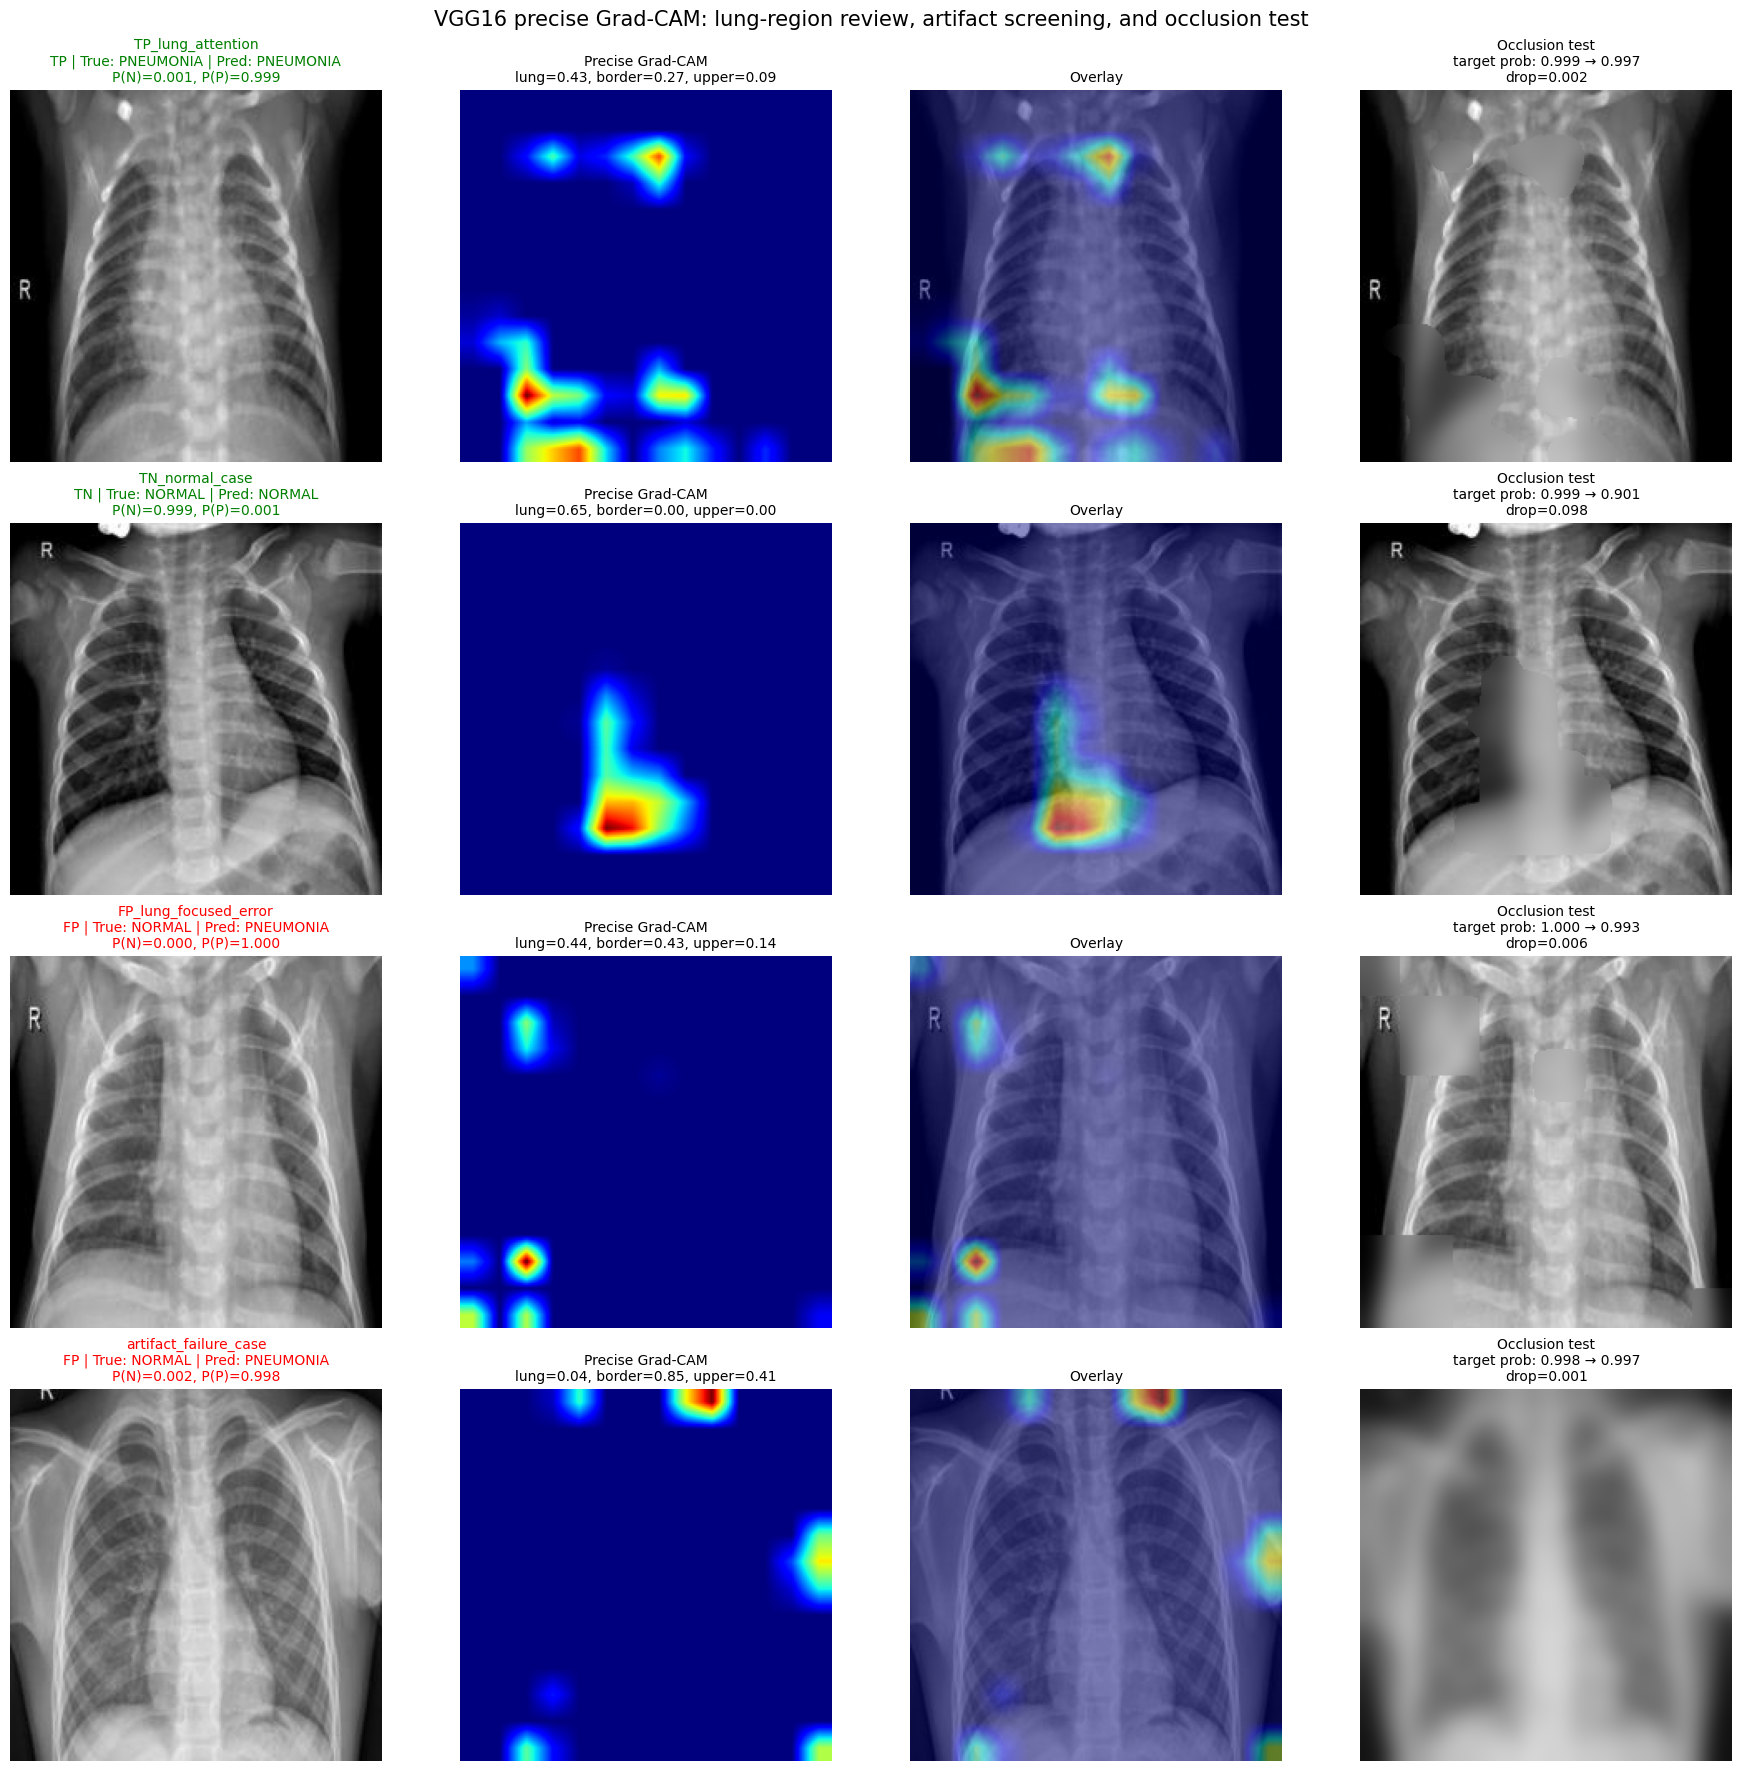

Saved final Grad-CAM report figure: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/final_report_cases/final_4_case_precise_gradcam_occlusion_report_figure.png
Saved occlusion results: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/final_report_cases/final_4_case_occlusion_results.csv


,review_id,case_type,true_class,pred_class,target_class,original_target_prob,occluded_target_prob,target_prob_drop,original_p_pneumonia,occluded_p_pneumonia,p_pneumonia_drop,top_quantile,fill_mode,occluded_area_ratio
0,1,TP,PNEUMONIA,PNEUMONIA,PNEUMONIA,0.998992,0.997346,0.001646,0.998992,0.997346,0.001646,0.85,blur,0.149912
1,7,TN,NORMAL,NORMAL,NORMAL,0.998941,0.901361,0.097580,0.001059,0.098639,-0.097580,0.85,blur,0.149673
2,15,FP,NORMAL,PNEUMONIA,PNEUMONIA,0.999545,0.993499,0.006046,0.999545,0.993499,0.006046,0.85,blur,0.150072
3,16,FP,NORMAL,PNEUMONIA,PNEUMONIA,0.998285,0.997021,0.001263,0.998285,0.997021,0.001263,0.85,blur,1.000000


In [84]:

# ============================================================
# 12. Final report figure with occlusion test
# ============================================================

def plot_final_four_grad_cam_figure(final_four_df_input_grad_cam):
    if len(final_four_df_input_grad_cam) == 0:
        print("No final Grad-CAM cases were selected.")
        return None, None

    n_cases_grad_cam = len(final_four_df_input_grad_cam)

    fig_grad_cam, axes_grad_cam = plt.subplots(
        n_cases_grad_cam,
        4,
        figsize=(18, 4.4 * n_cases_grad_cam),
        squeeze=False,
        constrained_layout=True,
    )

    occlusion_results_grad_cam = []

    for row_index_grad_cam, (_, row_grad_cam) in enumerate(final_four_df_input_grad_cam.iterrows()):
        occlusion_output_grad_cam = run_occlusion_test_grad_cam(
            row_grad_cam=row_grad_cam,
            target_mode_grad_cam="pred",
            target_score_mode_grad_cam="margin",
            top_quantile_grad_cam=0.85,
            fill_mode_grad_cam="blur",
        )

        image_rgb_grad_cam = occlusion_output_grad_cam["image_rgb"]
        heatmap_grad_cam = occlusion_output_grad_cam["heatmap"]
        overlay_rgb_grad_cam = occlusion_output_grad_cam["overlay_rgb"]
        occluded_image_rgb_grad_cam = occlusion_output_grad_cam["occluded_image_rgb"]
        occlusion_result_grad_cam = occlusion_output_grad_cam["occlusion_result"]

        occlusion_results_grad_cam.append(occlusion_result_grad_cam)

        title_color_grad_cam = "green" if bool(row_grad_cam["correct"]) else "red"

        axes_grad_cam[row_index_grad_cam, 0].imshow(image_rgb_grad_cam)
        axes_grad_cam[row_index_grad_cam, 0].set_title(
            (
                f"{row_grad_cam['report_role']}\n"
                f"{row_grad_cam['case_type']} | "
                f"True: {row_grad_cam['true_class']} | "
                f"Pred: {row_grad_cam['pred_class']}\n"
                f"P(N)={row_grad_cam['p_normal']:.3f}, "
                f"P(P)={row_grad_cam['p_pneumonia']:.3f}"
            ),
            fontsize=10,
            color=title_color_grad_cam,
        )
        axes_grad_cam[row_index_grad_cam, 0].axis("off")

        axes_grad_cam[row_index_grad_cam, 1].imshow(
            heatmap_grad_cam,
            cmap="jet",
            vmin=0,
            vmax=1,
        )
        axes_grad_cam[row_index_grad_cam, 1].set_title(
            (
                "Precise Grad-CAM\n"
                f"lung={row_grad_cam['rough_lung_attention_ratio']:.2f}, "
                f"border={row_grad_cam['border_attention_ratio']:.2f}, "
                f"upper={row_grad_cam['upper_attention_ratio']:.2f}"
            ),
            fontsize=10,
        )
        axes_grad_cam[row_index_grad_cam, 1].axis("off")

        axes_grad_cam[row_index_grad_cam, 2].imshow(overlay_rgb_grad_cam)
        axes_grad_cam[row_index_grad_cam, 2].set_title("Overlay", fontsize=10)
        axes_grad_cam[row_index_grad_cam, 2].axis("off")

        axes_grad_cam[row_index_grad_cam, 3].imshow(occluded_image_rgb_grad_cam)
        axes_grad_cam[row_index_grad_cam, 3].set_title(
            (
                "Occlusion test\n"
                f"target prob: "
                f"{occlusion_result_grad_cam['original_target_prob']:.3f}"
                f" → {occlusion_result_grad_cam['occluded_target_prob']:.3f}\n"
                f"drop={occlusion_result_grad_cam['target_prob_drop']:.3f}"
            ),
            fontsize=10,
        )
        axes_grad_cam[row_index_grad_cam, 3].axis("off")

    fig_grad_cam.suptitle(
        (
            "VGG16 precise Grad-CAM: "
            "lung-region review, artifact screening, and occlusion test"
        ),
        fontsize=15,
    )

    final_figure_path_grad_cam = os.path.join(
        grad_cam_final_fpath,
        "final_4_case_precise_gradcam_occlusion_report_figure.png",
    )

    fig_grad_cam.savefig(final_figure_path_grad_cam, dpi=300, bbox_inches="tight")
    plt.show()

    occlusion_results_df_grad_cam = pd.DataFrame(occlusion_results_grad_cam)

    occlusion_results_csv_grad_cam = os.path.join(
        grad_cam_final_fpath,
        "final_4_case_occlusion_results.csv",
    )

    occlusion_results_df_grad_cam.to_csv(occlusion_results_csv_grad_cam, index=False)

    print("Saved final Grad-CAM report figure:", final_figure_path_grad_cam)
    print("Saved occlusion results:", occlusion_results_csv_grad_cam)

    display(occlusion_results_df_grad_cam)

    return final_figure_path_grad_cam, occlusion_results_csv_grad_cam


final_figure_path_grad_cam, occlusion_results_csv_grad_cam = plot_final_four_grad_cam_figure(
    final_four_df_input_grad_cam=final_four_df_grad_cam
)



In [85]:
# ============================================================
# 13. Save report-ready interpretation
# ============================================================

def build_report_summary_grad_cam(final_four_df_input_grad_cam, occlusion_csv_path_grad_cam):
    if len(final_four_df_input_grad_cam) == 0:
        return "No final Grad-CAM cases were selected."

    if occlusion_csv_path_grad_cam is None:
        return "No occlusion results were generated."

    occlusion_df_grad_cam = pd.read_csv(occlusion_csv_path_grad_cam)

    summary_lines_grad_cam = []

    for _, row_grad_cam in final_four_df_input_grad_cam.iterrows():
        review_id_grad_cam = int(row_grad_cam["review_id"])

        occ_row_grad_cam = occlusion_df_grad_cam[
            occlusion_df_grad_cam["review_id"] == review_id_grad_cam
        ]

        if len(occ_row_grad_cam) > 0:
            occ_row_grad_cam = occ_row_grad_cam.iloc[0]
            occlusion_text_grad_cam = (
                f"After occluding the most activated Grad-CAM region, "
                f"the target-class probability changed from "
                f"{occ_row_grad_cam['original_target_prob']:.3f} to "
                f"{occ_row_grad_cam['occluded_target_prob']:.3f} "
                f"(drop = {occ_row_grad_cam['target_prob_drop']:.3f})."
            )
        else:
            occlusion_text_grad_cam = "The occlusion result was not available."

        if (
            row_grad_cam["rough_lung_attention_ratio"] >= 0.55
            and row_grad_cam["border_attention_ratio"] < 0.30
        ):
            location_text_grad_cam = (
                "The heatmap was mainly concentrated within the rough lung-field region."
            )
        elif (
            row_grad_cam["border_attention_ratio"] >= 0.30
            or row_grad_cam["upper_attention_ratio"] >= 0.40
        ):
            location_text_grad_cam = (
                "The heatmap showed substantial attention to peripheral or upper-image regions, "
                "suggesting possible shortcut learning."
            )
        else:
            location_text_grad_cam = (
                "The heatmap location was mixed and should be interpreted cautiously."
            )

        line_grad_cam = (
            f"{row_grad_cam['report_role']} "
            f"(Review ID {review_id_grad_cam}, {row_grad_cam['case_type']}, "
            f"true={row_grad_cam['true_class']}, predicted={row_grad_cam['pred_class']}): "
            f"{location_text_grad_cam} "
            f"The rough lung attention ratio was "
            f"{row_grad_cam['rough_lung_attention_ratio']:.3f}, "
            f"the border attention ratio was "
            f"{row_grad_cam['border_attention_ratio']:.3f}, "
            f"and the upper-image attention ratio was "
            f"{row_grad_cam['upper_attention_ratio']:.3f}. "
            f"{occlusion_text_grad_cam}"
        )

        summary_lines_grad_cam.append(line_grad_cam)

    return "\n\n".join(summary_lines_grad_cam)


if occlusion_results_csv_grad_cam is not None:
    report_summary_grad_cam = build_report_summary_grad_cam(
        final_four_df_input_grad_cam=final_four_df_grad_cam,
        occlusion_csv_path_grad_cam=occlusion_results_csv_grad_cam,
    )

    report_summary_path_grad_cam = os.path.join(
        grad_cam_final_fpath,
        "final_4_case_gradcam_report_summary.txt",
    )

    with open(report_summary_path_grad_cam, "w", encoding="utf-8") as file_grad_cam:
        file_grad_cam.write(report_summary_grad_cam)

    print("Saved report summary:", report_summary_path_grad_cam)
    print(report_summary_grad_cam)

Saved report summary: /content/drive/MyDrive/Google AI Studio/model_output/gradcam_vgg16_precise_continuation/final_report_cases/final_4_case_gradcam_report_summary.txt
TP_lung_attention (Review ID 1, TP, true=PNEUMONIA, predicted=PNEUMONIA): The heatmap location was mixed and should be interpreted cautiously. The rough lung attention ratio was 0.426, the border attention ratio was 0.275, and the upper-image attention ratio was 0.093. After occluding the most activated Grad-CAM region, the target-class probability changed from 0.999 to 0.997 (drop = 0.002).

TN_normal_case (Review ID 7, TN, true=NORMAL, predicted=NORMAL): The heatmap was mainly concentrated within the rough lung-field region. The rough lung attention ratio was 0.650, the border attention ratio was 0.000, and the upper-image attention ratio was 0.000. After occluding the most activated Grad-CAM region, the target-class probability changed from 0.999 to 0.901 (drop = 0.098).

FP_lung_focused_error (Review ID 15, FP, true